In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
X = 6*np.random.rand(200,1)-3
y = 0.8*X**2 + 0.9 * X + 2 + np.random.randn(200,1)

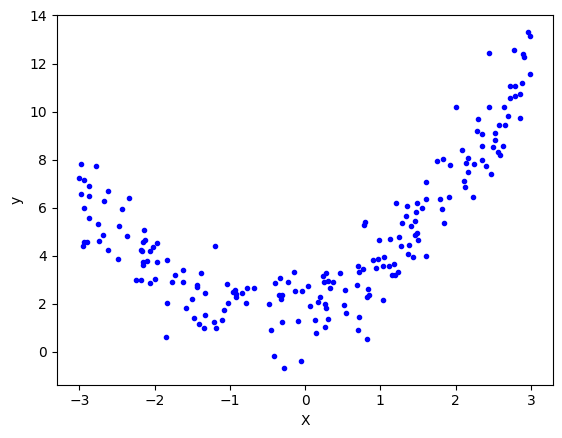

In [4]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

## Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2 ,random_state=3)

## Applying the linear Regression Model

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = lr.predict(X_test)

In [8]:
r2_score_lr = r2_score(y_test, y_pred)
print("R2_score: ", r2_score_lr)

R2_score:  0.29347895549350433


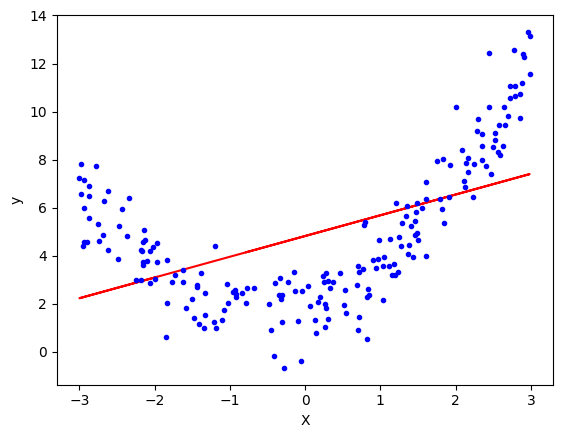

In [9]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

## Applying Polynomial Linear Regression

In [13]:
poly = PolynomialFeatures(degree = 2,include_bias=True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit(X_test)

In [11]:
print(X_train[0])

[-1.97164399]


In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Initialize the transformer
poly = PolynomialFeatures(degree=2)

# 2. Transform the ORIGINAL training data (X_train)
X_poly_train = poly.fit_transform(X_train) 

# 3. Fit the model on the TRANSFORMED data
lr = LinearRegression()
lr.fit(X_poly_train, y_train) # lr now expects 3 features

# 4. Now your prediction code will work
X_new = np.linspace(-3, 3, 200).reshape(200, 1) # Note: used (-3, 3) instead of (-3, -3)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

In [21]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

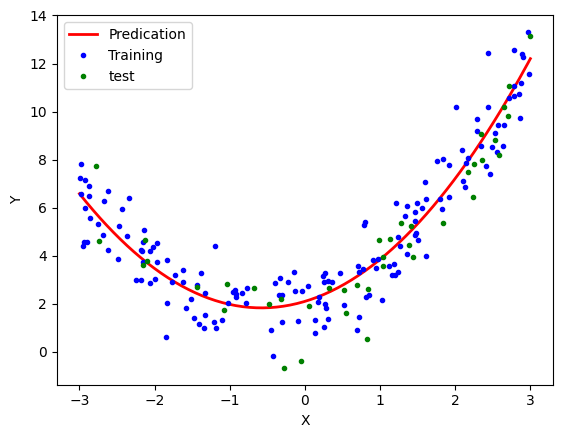

In [23]:
plt.plot(X_new, y_new,'r', linewidth=2,label='Predication')
plt.plot(X_train,y_train, 'b.', label='Training')
plt.plot(X_test,y_test,'g.',label='test')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()